[1] 라이브러리 import + 경로 설정

In [50]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import librosa
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'AppleGothic'   # 한글 폰트
warnings.filterwarnings("ignore")                    # 경고 숨김

BASE       = "/Users/jinbaaaaang/Downloads/New_Sample"   # 데이터셋 기본 경로
LABEL_ROOT = os.path.join(BASE, "라벨링데이터", "TL_common_01")   # JSON 라벨 경로
WAV_ROOT   = os.path.join(BASE, "원천데이터", "TS_common_01")     # WAV 음성 경로

WINDOW_SECS     = [0.5, 1.0, 1.5, 3.0, None]   # 자를 길이(초), None은 전체 길이
SR              = 16000                        # 샘플링 주파수
HOP_LENGTH      = 160                          # 프레임 이동 길이
N_MFCC          = 13                           # MFCC 개수
MAX_PER_SPEAKER = 9999                         # 화자당 최대 파일 수

print("설정 완료")
print(f"LABEL_ROOT: {LABEL_ROOT}")
print(f"WAV_ROOT:   {WAV_ROOT}")

설정 완료
LABEL_ROOT: /Users/jinbaaaaang/Downloads/New_Sample/라벨링데이터/TL_common_01
WAV_ROOT:   /Users/jinbaaaaang/Downloads/New_Sample/원천데이터/TS_common_01


[2] 파일 목록 수집

In [ ]:
def get_file_pairs():
    pairs = []

    # 날짜 폴더별로 순회
    for date_folder in sorted(os.listdir(LABEL_ROOT)):
        label_date = os.path.join(LABEL_ROOT, date_folder)
        wav_date   = os.path.join(WAV_ROOT,   date_folder)

        if not os.path.isdir(label_date):
            continue

        # 날짜 폴더 안의 화자별 폴더 순회
        for speaker_id in sorted(os.listdir(label_date)):
            label_spk = os.path.join(label_date, speaker_id)
            wav_spk   = os.path.join(wav_date,   speaker_id)

            if not os.path.isdir(label_spk):
                continue

            json_files = sorted([f for f in os.listdir(label_spk)
                                if f.endswith(".json")])
            json_files = json_files[:MAX_PER_SPEAKER]   # 화자당 최대 파일 수 제한

            # JSON 파일과 같은 이름의 WAV 파일 연결
            for jf in json_files:
                json_path = os.path.join(label_spk, jf)
                wav_path  = os.path.join(wav_spk, jf.replace(".json", ".wav"))

                if os.path.exists(wav_path):
                    pairs.append((wav_path, json_path, speaker_id))

    return pairs


pairs    = get_file_pairs()
speakers = sorted(set(p[2] for p in pairs))   # 중복 없는 화자 목록

print(f"총 파일 수: {len(pairs)}개")
print(f"화자 수:    {len(speakers)}명")
print(f"화자 목록:  {speakers}")

총 파일 수: 4835개
화자 수:    50명
화자 목록:  ['0047', '0121', '0134', '0195', '0275', '0301', '0375', '0438', '0601', '0631', '0659', '0719', '0756', '0857', '0862', '0936', '1001', '1017', '1262', '1303', '1315', '1323', '1401', '1461', '1574', '1591', '1653', '1756', '1836', '1901', '2052', '2057', '2096', '2097', '2205', '2247', '2321', '2335', '2344', '2363', '2367', '2399', '2415', '2439', '2468', '2513', '2572', '2594', '2620', '2636']


[3] 델타 MFCC + Pitch + Energy 피처 추출 함수 + 테스트

In [ ]:
def extract_delta(wav_path, json_path, window_sec):
    try:
        with open(json_path, encoding="utf-8") as f:
            meta = json.load(f)

        offset   = float(meta["Other"]["SpeechStart"])
        end_time = float(meta["Other"]["SpeechEnd"])
        duration = end_time - offset

        # 사용할 발화 길이 설정
        if window_sec is None:
            load_duration = duration
        else:
            if duration < window_sec:
                return None
            load_duration = window_sec

        # 발화 시작 시점부터 필요한 길이만 로드
        y, _ = librosa.load(wav_path, sr=SR,
                            offset=offset,
                            duration=load_duration)

        # MFCC, 델타, 델타델타 추출
        mfcc   = librosa.feature.mfcc(y=y, sr=SR,
                                    n_mfcc=N_MFCC,
                                    hop_length=HOP_LENGTH)
        delta  = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        combined  = np.concatenate([mfcc, delta, delta2], axis=0)
        mfcc_feat = np.concatenate([combined.mean(axis=1),
                                    combined.std(axis=1)])   # 78차원

        # Pitch 특징 추출
        pitch = librosa.yin(y, fmin=50, fmax=400,
                            hop_length=HOP_LENGTH)
        pitch_voiced = pitch[pitch > 0]

        if len(pitch_voiced) == 0:
            pitch_voiced = np.array([0.0])

        pitch_feat = np.array([
            pitch_voiced.mean(),
            pitch_voiced.std(),
            pitch_voiced.max(),
            pitch_voiced.min(),
        ])   # 4차원

        # Energy 특징 추출
        energy = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)[0]
        energy_feat = np.array([
            energy.mean(),
            energy.std(),
            energy.max(),
        ])   # 3차원

        # 전체 특징 벡터 결합
        feat = np.concatenate([mfcc_feat, pitch_feat, energy_feat])   # 총 85차원
        return feat

    except Exception as e:
        print(f"  스킵: {os.path.basename(wav_path)} ({e})")
        return None


# 테스트
wav_path, json_path, spk = pairs[0]
feat_test = extract_delta(wav_path, json_path, 1.0)

print(f"피처 추출 성공!")
print(f"shape: {feat_test.shape}")   # (85,)이면 정상
print(f"화자:  {spk}")

피처 추출 성공!
shape: (85,)
화자:  0047


[4] 파일 기준 Train / Val 분리

In [ ]:
train_pairs = []
val_pairs   = []

# 화자별로 파일을 8:2로 분할
for speaker_id in speakers:
    spk_files = [p for p in pairs if p[2] == speaker_id]

    if len(spk_files) < 2:
        train_pairs.extend(spk_files)   # 파일이 너무 적으면 train에만 사용
        continue

    split = int(len(spk_files) * 0.8)
    train_pairs.extend(spk_files[:split])
    val_pairs.extend(spk_files[split:])

print(f"Train 파일 수: {len(train_pairs)}개")
print(f"Val   파일 수: {len(val_pairs)}개")
print(f"Train 화자 수: {len(set(p[2] for p in train_pairs))}명")
print(f"Val   화자 수: {len(set(p[2] for p in val_pairs))}명")

Train 파일 수: 3855개
Val   파일 수: 980개
Train 화자 수: 50명
Val   화자 수: 49명


[5] 핵심 실험 — 윈도우별 정확도 측정

In [ ]:
from sklearn.svm import SVC
from catboost import CatBoostClassifier

# 사용할 분류 모델 정의
models = {
    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=7,
        max_depth=4,
        min_child_samples=20,
        subsample=0.6,
        colsample_bytree=0.6,
        reg_alpha=1.0,
        reg_lambda=5.0,
        n_jobs=-1,
        verbose=-1
    ),
    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=4,
        verbose=0,
        random_seed=42
    ),
}

# 모델별 결과 저장
all_results = {model_name: [] for model_name in models}

# 입력 길이별 반복 실험
for window_sec in WINDOW_SECS:
    label = f"{window_sec}초" if window_sec is not None else "전체"
    print(f"\n{'='*40}")
    print(f"▶ window = {label} 처리 중...")

    X_train_raw, y_train = [], []
    X_val_raw,   y_val   = [], []

    # Train 데이터 피처 추출
    for wav_path, json_path, speaker_id in train_pairs:
        feat = extract_delta(wav_path, json_path, window_sec)
        if feat is None:
            continue
        X_train_raw.append(feat)
        y_train.append(speaker_id)

    # Validation 데이터 피처 추출
    for wav_path, json_path, speaker_id in val_pairs:
        feat = extract_delta(wav_path, json_path, window_sec)
        if feat is None:
            continue
        X_val_raw.append(feat)
        y_val.append(speaker_id)

    if not X_train_raw or not X_val_raw:
        print("  데이터 부족 — 스킵")
        continue

    X_train_raw = np.array(X_train_raw)
    X_val_raw   = np.array(X_val_raw)

    # 표준화
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train_raw)
    X_val_sc   = scaler.transform(X_val_raw)

    y_train_arr = np.array(y_train)
    y_val_arr   = np.array(y_val)

    # 모델별 학습 및 평가
    for model_name, model in models.items():
        print(f"  [{model_name}] 학습 중...")

        model.fit(X_train_sc, y_train_arr)

        acc_train = accuracy_score(y_train_arr, model.predict(X_train_sc))
        acc_val   = accuracy_score(y_val_arr, model.predict(X_val_sc))

        # 예측 확률 기반 코사인 유사도 계산
        proba_val = model.predict_proba(X_val_sc)

        # 화자당 최대 5개 샘플만 사용
        np.random.seed(42)
        sampled_idx = []

        for spk in sorted(set(y_val_arr)):
            spk_idx = np.where(y_val_arr == spk)[0]
            n = min(5, len(spk_idx))
            sampled_idx.extend(np.random.choice(spk_idx, n, replace=False))

        sampled_idx  = np.array(sampled_idx)
        proba_sample = proba_val[sampled_idx]
        y_sample     = y_val_arr[sampled_idx]

        # 같은 화자 / 다른 화자 간 유사도 분리
        same_sim, diff_sim = [], []

        for i in range(len(proba_sample)):
            for j in range(len(proba_sample)):
                if i == j:
                    continue

                v1  = proba_sample[i].reshape(1, -1)
                v2  = proba_sample[j].reshape(1, -1)
                sim = cosine_similarity(v1, v2)[0][0]

                if y_sample[i] == y_sample[j]:
                    same_sim.append(sim)
                else:
                    diff_sim.append(sim)

        avg_same = np.mean(same_sim) if same_sim else 0.0
        avg_diff = np.mean(diff_sim) if diff_sim else 0.0

        # 결과 저장
        all_results[model_name].append({
            "window_sec": window_sec,
            "label":      label,
            "train_acc":  acc_train,
            "val_acc":    acc_val,
            "gap":        acc_train - acc_val,
            "same_sim":   avg_same,
            "diff_sim":   avg_diff,
        })

        print(f"    Train: {acc_train:.1%}  "
            f"Val: {acc_val:.1%}  "
            f"Gap: {acc_train - acc_val:.1%}  "
            f"같은화자: {avg_same:.4f}  "
            f"다른화자: {avg_diff:.4f}")

print("\n실험 완료!")


▶ window = 0.5초 처리 중...
  [LightGBM] 학습 중...
    Train: 97.0%  Val: 58.7%  Gap: 38.2%  같은화자: 0.5761  다른화자: 0.1383
  [SVM] 학습 중...
    Train: 94.9%  Val: 64.4%  Gap: 30.6%  같은화자: 0.6370  다른화자: 0.0956
  [CatBoost] 학습 중...
    Train: 82.9%  Val: 60.5%  Gap: 22.4%  같은화자: 0.6624  다른화자: 0.2192

▶ window = 1.0초 처리 중...
  [LightGBM] 학습 중...
    Train: 98.6%  Val: 68.5%  Gap: 30.1%  같은화자: 0.6328  다른화자: 0.1004
  [SVM] 학습 중...
    Train: 97.1%  Val: 74.8%  Gap: 22.3%  같은화자: 0.6739  다른화자: 0.0806
  [CatBoost] 학습 중...
    Train: 89.5%  Val: 69.3%  Gap: 20.1%  같은화자: 0.7041  다른화자: 0.1511

▶ window = 1.5초 처리 중...
  [LightGBM] 학습 중...
    Train: 99.1%  Val: 72.3%  Gap: 26.8%  같은화자: 0.6838  다른화자: 0.0805
  [SVM] 학습 중...
    Train: 97.8%  Val: 79.5%  Gap: 18.3%  같은화자: 0.7257  다른화자: 0.0737
  [CatBoost] 학습 중...
    Train: 91.4%  Val: 73.9%  Gap: 17.6%  같은화자: 0.7340  다른화자: 0.1253

▶ window = 3.0초 처리 중...
  [LightGBM] 학습 중...
    Train: 98.3%  Val: 80.3%  Gap: 18.0%  같은화자: 0.7638  다른화자: 0.1679
  [SVM] 학습 중...

[6] 결과 시각화

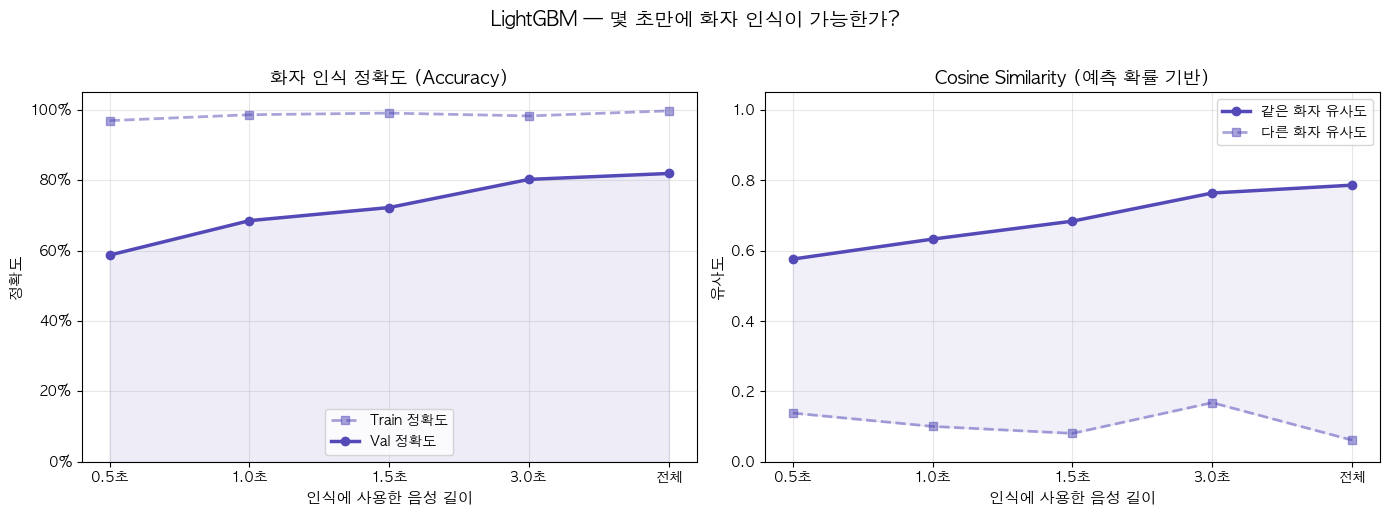

→ result_LightGBM.png 저장 완료


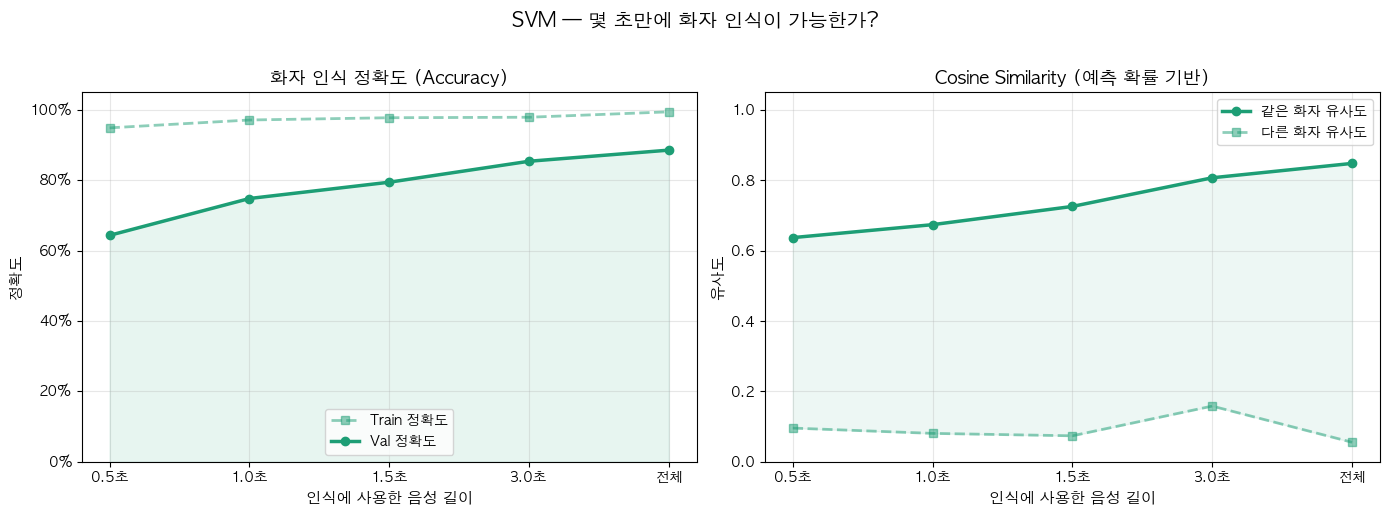

→ result_SVM.png 저장 완료


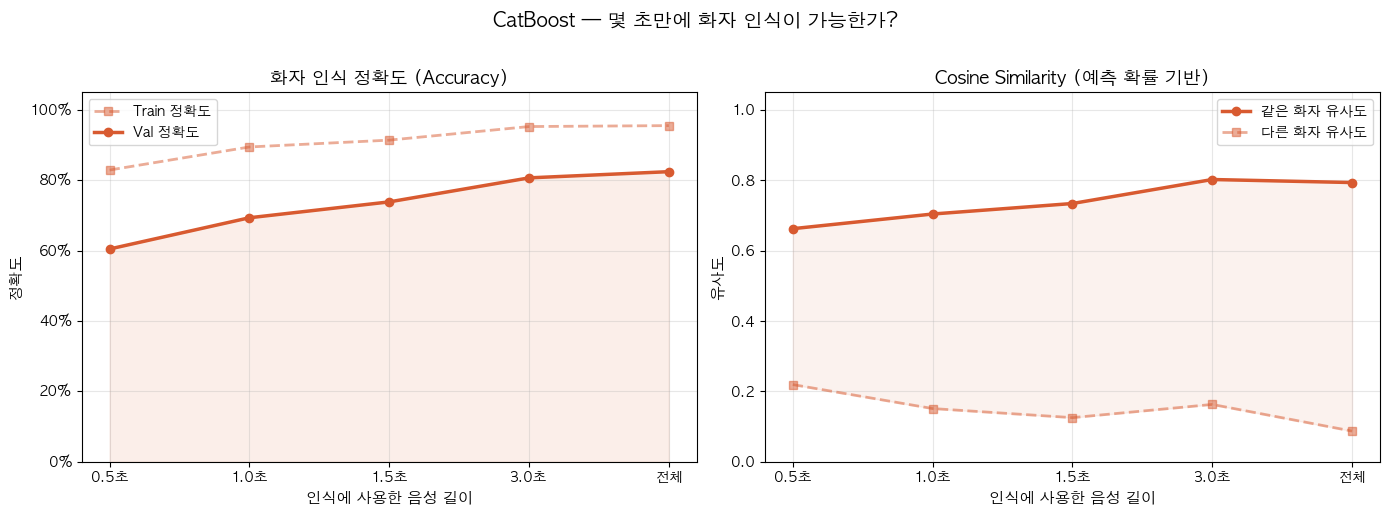

→ result_CatBoost.png 저장 완료


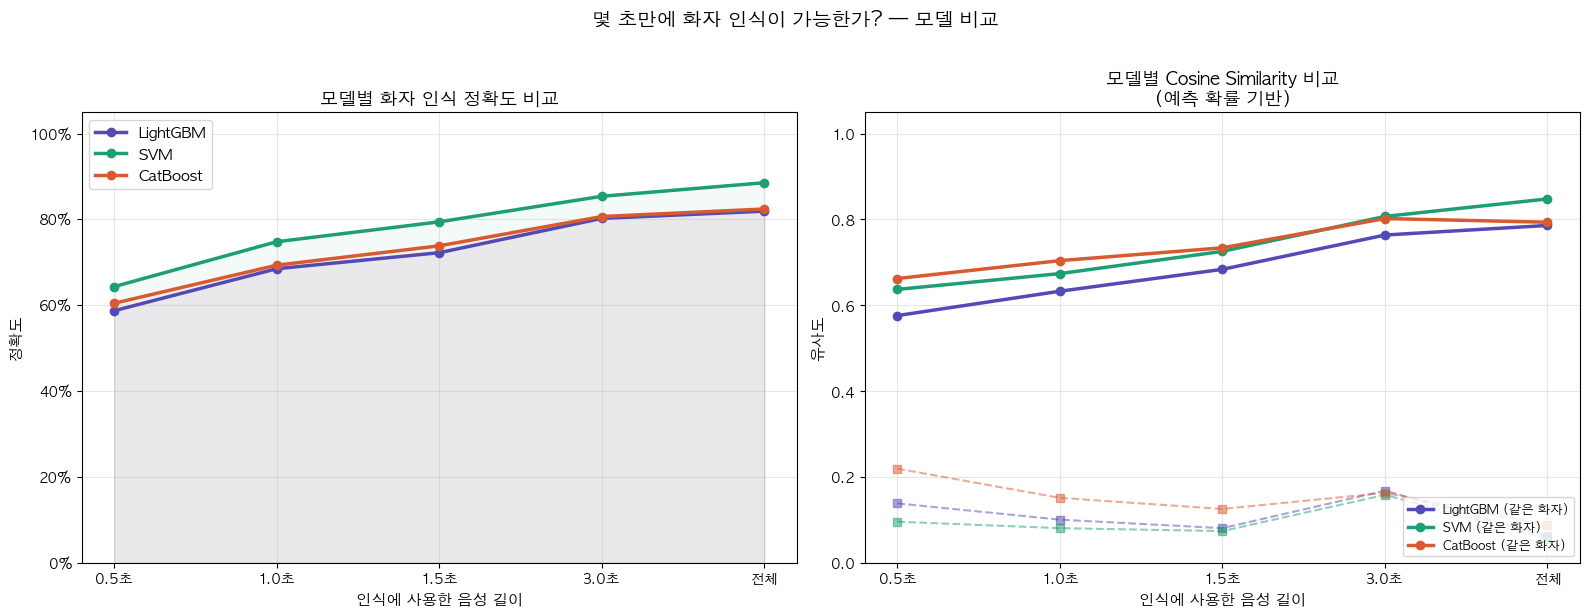

→ result_all_models.png 저장 완료

=== 모델별 최종 결과 ===

[ LightGBM ]
label  train_acc  val_acc      gap  same_sim  diff_sim
 0.5초   0.969579 0.587334 0.382245  0.576057  0.138309
 1.0초   0.986345 0.685243 0.301102  0.632789  0.100403
 1.5초   0.990949 0.722603 0.268346  0.683818  0.080549
 3.0초   0.982987 0.802575 0.180412  0.763783  0.167861
   전체   0.997406 0.819388 0.178018  0.786148  0.061368

[ SVM ]
label  train_acc  val_acc      gap  same_sim  diff_sim
 0.5초   0.949038 0.643514 0.305524  0.637030  0.095637
 1.0초   0.971376 0.748194 0.223182  0.673863  0.080558
 1.5초   0.977810 0.794521 0.183290  0.725698  0.073683
 3.0초   0.979206 0.854077 0.125129  0.807126  0.158166
   전체   0.994553 0.885714 0.108838  0.847971  0.055307

[ CatBoost ]
label  train_acc  val_acc      gap  same_sim  diff_sim
 0.5초   0.829173 0.604699 0.224474  0.662415  0.219237
 1.0초   0.894695 0.693498 0.201197  0.704100  0.151124
 1.5초   0.914161 0.738584 0.175576  0.733975  0.125292
 3.0초   0.952741 0.806867 0.145874

In [ ]:
colors = {
    "LightGBM": "#534AB7",
    "SVM":      "#1D9E75",
    "CatBoost": "#D85A30",
}

x_values = list(range(len(WINDOW_SECS)))
x_labels = [f"{w}초" if w is not None else "전체" for w in WINDOW_SECS]

# 모델별 개별 그래프 저장
for model_name, res_list in all_results.items():
    res   = pd.DataFrame(res_list)
    color = colors[model_name]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 정확도 그래프
    axes[0].plot(x_values[:len(res)], res["train_acc"],
                marker="s", linewidth=2, linestyle="--",
                color=color, alpha=0.5, label="Train 정확도")
    axes[0].plot(x_values[:len(res)], res["val_acc"],
                marker="o", linewidth=2.5,
                color=color, label="Val 정확도")
    axes[0].fill_between(x_values[:len(res)], res["val_acc"],
                        alpha=0.1, color=color)
    axes[0].set_title("화자 인식 정확도 (Accuracy)", fontsize=13)
    axes[0].set_xlabel("인식에 사용한 음성 길이", fontsize=11)
    axes[0].set_ylabel("정확도", fontsize=11)
    axes[0].set_xticks(x_values)
    axes[0].set_xticklabels(x_labels, fontsize=10)
    axes[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    axes[0].set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # 코사인 유사도 그래프
    axes[1].plot(x_values[:len(res)], res["same_sim"],
                marker="o", linewidth=2.5,
                color=color, label="같은 화자 유사도")
    axes[1].plot(x_values[:len(res)], res["diff_sim"],
                marker="s", linewidth=2, linestyle="--",
                color=color, alpha=0.5, label="다른 화자 유사도")
    axes[1].fill_between(x_values[:len(res)],
                        res["same_sim"], res["diff_sim"],
                        alpha=0.08, color=color)
    axes[1].set_title("Cosine Similarity (예측 확률 기반)", fontsize=13)
    axes[1].set_xlabel("인식에 사용한 음성 길이", fontsize=11)
    axes[1].set_ylabel("유사도", fontsize=11)
    axes[1].set_xticks(x_values)
    axes[1].set_xticklabels(x_labels, fontsize=10)
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"{model_name} — 몇 초만에 화자 인식이 가능한가?",
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f"result_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"→ result_{model_name}.png 저장 완료")


# 모델 전체 비교 그래프 저장
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 정확도 비교 그래프
for model_name, res_list in all_results.items():
    res = pd.DataFrame(res_list)
    axes[0].plot(x_values[:len(res)], res["val_acc"],
                marker="o", linewidth=2.5,
                color=colors[model_name],
                label=model_name)
    axes[0].fill_between(x_values[:len(res)], res["val_acc"],
                        alpha=0.05, color=colors[model_name])

axes[0].set_title("모델별 화자 인식 정확도 비교", fontsize=13)
axes[0].set_xlabel("인식에 사용한 음성 길이", fontsize=11)
axes[0].set_ylabel("정확도", fontsize=11)
axes[0].set_xticks(x_values)
axes[0].set_xticklabels(x_labels, fontsize=10)
axes[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[0].set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 코사인 유사도 비교 그래프
for model_name, res_list in all_results.items():
    res = pd.DataFrame(res_list)
    axes[1].plot(x_values[:len(res)], res["same_sim"],
                marker="o", linewidth=2.5,
                color=colors[model_name],
                label=f"{model_name} (같은 화자)")
    axes[1].plot(x_values[:len(res)], res["diff_sim"],
                marker="s", linewidth=1.5, linestyle="--",
                color=colors[model_name], alpha=0.5)

axes[1].set_title("모델별 Cosine Similarity 비교\n(예측 확률 기반)", fontsize=13)
axes[1].set_xlabel("인식에 사용한 음성 길이", fontsize=11)
axes[1].set_ylabel("유사도", fontsize=11)
axes[1].set_xticks(x_values)
axes[1].set_xticklabels(x_labels, fontsize=10)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9, loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.suptitle("몇 초만에 화자 인식이 가능한가? — 모델 비교",
            fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("result_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ result_all_models.png 저장 완료")


# 결과 표 출력
print("\n=== 모델별 최종 결과 ===")
for model_name, res_list in all_results.items():
    res = pd.DataFrame(res_list)
    print(f"\n[ {model_name} ]")
    print(res[["label", "train_acc", "val_acc",
                "gap", "same_sim", "diff_sim"]].to_string(index=False))